In [3]:
#setup 
__author__ = 'SherlockLiao'

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import os

if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')
    
print ("setup done")

setup done


In [4]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

In [ ]:
#hyperparameters
num_epochs = 100
batch_size = 128
learning_rate = 1e-3

In [6]:
#Data loading
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

dataset = MNIST('./data', transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))



Number of batches: 469


In [7]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [8]:
#Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2),  # b, 16, 5, 5
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 5, stride=3, padding=1),  # b, 8, 15, 15
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 2, stride=2, padding=1),  # b, 1, 28, 28
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print ("model defined")


model defined


In [9]:
#Model and optimizer
model = autoencoder()

# load model if exists, after finalizing on the model, this can be used.
#if os.path.exists("conv_autoencoder.pth"):
    #model.load_state_dict(torch.load("conv_autoencoder.pth"))
    #print("Loaded previous model weights")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                             weight_decay=1e-5)

In [ ]:
#visualize of noise and denoising.
# using noise of 0.3, strong noise to test quality of reconstruction
def visualize(model, dataloader, epoch, sigma=0.3):
    img, _ = next(iter(dataloader))

    noisy_img = add_noise(img, sigma)

    # no_grad (forward pass only,since we are using the resulted weights)
    with torch.no_grad():
        output = model(noisy_img)

    orig = to_img(img)
    noisy = to_img(noisy_img)
    recon = to_img(output)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(orig[0][0], cmap='gray') #plot first image in batch

    plt.subplot(1,3,2)
    plt.title(f"Noisy σ={sigma}")
    plt.imshow(noisy[0][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon[0][0], cmap='gray')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

epoch [1/50], loss:228.5487


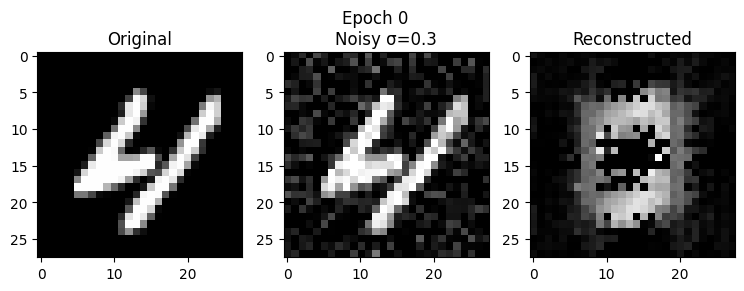

epoch [2/50], loss:117.4772
epoch [3/50], loss:83.1141
epoch [4/50], loss:74.2151
epoch [5/50], loss:69.8595
epoch [6/50], loss:67.3299
epoch [7/50], loss:65.5188
epoch [8/50], loss:63.9357
epoch [9/50], loss:62.5013
epoch [10/50], loss:61.3258
epoch [11/50], loss:60.4184


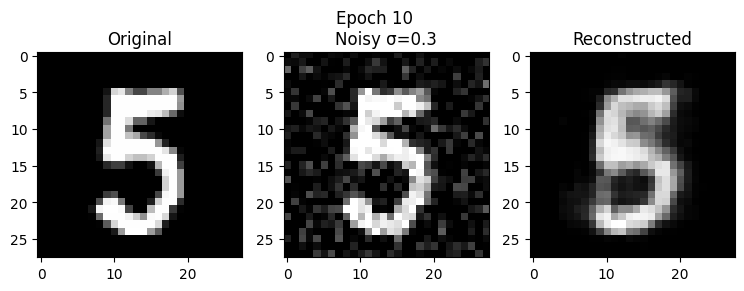

epoch [12/50], loss:59.6258
epoch [13/50], loss:58.8539
epoch [14/50], loss:58.2210
epoch [15/50], loss:57.4426
epoch [16/50], loss:56.9227
epoch [17/50], loss:56.4825
epoch [18/50], loss:56.1774
epoch [19/50], loss:55.7189
epoch [20/50], loss:55.3684
epoch [21/50], loss:55.0327


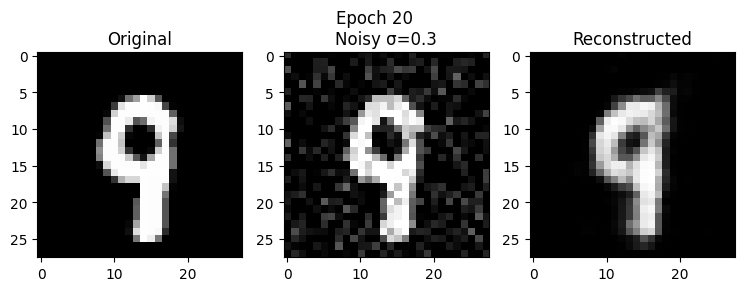

epoch [22/50], loss:54.8904
epoch [23/50], loss:54.5398
epoch [24/50], loss:54.2144
epoch [25/50], loss:54.0177
epoch [26/50], loss:53.7744
epoch [27/50], loss:53.4858
epoch [28/50], loss:53.3648
epoch [29/50], loss:53.0921
epoch [30/50], loss:52.9217
epoch [31/50], loss:52.7190


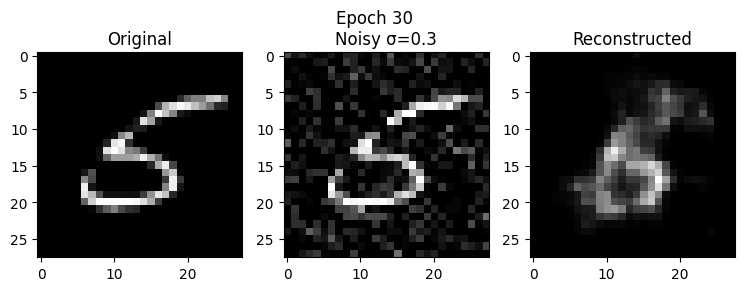

epoch [32/50], loss:52.5693
epoch [33/50], loss:52.3706
epoch [34/50], loss:52.3675
epoch [35/50], loss:52.1485
epoch [36/50], loss:52.0293
epoch [37/50], loss:51.7567
epoch [38/50], loss:51.8291
epoch [39/50], loss:51.7717
epoch [40/50], loss:51.6425
epoch [41/50], loss:51.3133


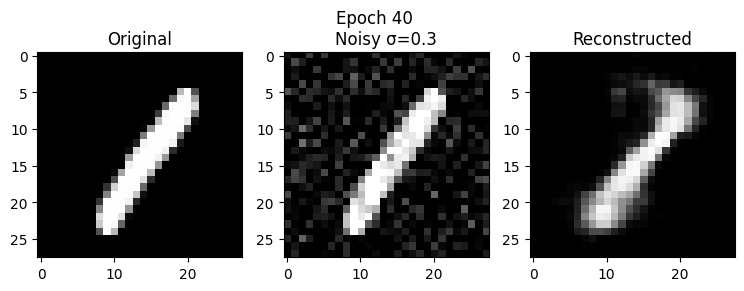

epoch [42/50], loss:51.2838
epoch [43/50], loss:51.1958
epoch [44/50], loss:51.2126
epoch [45/50], loss:51.1866
epoch [46/50], loss:50.9980
epoch [47/50], loss:50.9102
epoch [48/50], loss:50.9416
epoch [49/50], loss:50.7637
epoch [50/50], loss:50.7309


In [11]:
#Training loop
for epoch in range(num_epochs):
    total_loss = 0
    for data in dataloader:
        img, _ = data
        img = Variable(img)
        sigma = random.choice([0.1, 0.2, 0.3])
        noisy_img = add_noise(img, sigma=sigma)
        # ===================forward=====================
        output = model(noisy_img)
        loss = criterion(output, img)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.data
    # ===================log========================
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch+1, num_epochs, total_loss))
    if epoch % 10 == 0:
        visualize(model, dataloader, epoch) # visualize every 10 epochs
        pic = to_img(output.cpu().data)
        save_image(pic, './dc_img/image_{}.png'.format(epoch)) #saves images from the batch (recosntructed images) in a grid layout

In [12]:
#save model
torch.save(model.state_dict(), './conv_autoencoder.pth')